In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

In [2]:
titanic = sns.load_dataset("titanic")

leaks = ["alive", "who", "adult_male", "class", "embark_town", "alone", "deck"]
df = titanic.drop(columns=leaks)
print(df.shape)
df.head()

(891, 8)


,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [3]:
df["is_alone"] = ((df["sibsp"] + df["parch"]) == 0).astype(int)

# did we rebuild seaborn's "alone" column correctly?
matches = (df["is_alone"] == titanic["alone"].astype(int)).all()
print("is_alone matches the original alone column:", matches)

numeric = ["age", "fare", "sibsp", "parch", "is_alone"]
categorical = ["sex", "embarked"]
ordinal = ["pclass"]

is_alone matches the original alone column: True


In [4]:
X = df.drop(columns="survived")
y = df["survived"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_val.shape)

(712, 8) (179, 8)


In [5]:
numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

In [6]:
ordinal_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(categories=[[1, 2, 3]])),
])

In [7]:
preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric),
    ("cat", categorical_pipe, categorical),
    ("ord", ordinal_pipe, ordinal),
])

X_train_t = preprocessor.fit_transform(X_train)
X_val_t = preprocessor.transform(X_val)
print(X.shape[1], "->", X_train_t.shape[1])

8 -> 11


In [8]:
names = preprocessor.get_feature_names_out()
clean = pd.DataFrame(X_train_t, columns=names)
clean.head()

,num__age,num__fare,num__sibsp,num__parch,num__is_alone,cat__sex_female,cat__sex_male,cat__embarked_C,cat__embarked_Q,cat__embarked_S,ord__pclass
0,-0.081135,0.513812,-0.465084,-0.466183,0.800346,0.0,1.0,0.0,0.0,1.0,2.0
1,-0.081135,-0.662563,-0.465084,-0.466183,0.800346,0.0,1.0,0.0,0.0,1.0,1.0
2,-0.081135,3.955399,-0.465084,-0.466183,0.800346,0.0,1.0,0.0,0.0,1.0,0.0
3,-0.887827,-0.467874,-0.465084,0.727782,-1.249460,1.0,0.0,0.0,0.0,1.0,2.0
4,0.110934,-0.115977,0.478335,0.727782,-1.249460,1.0,0.0,0.0,0.0,1.0,1.0


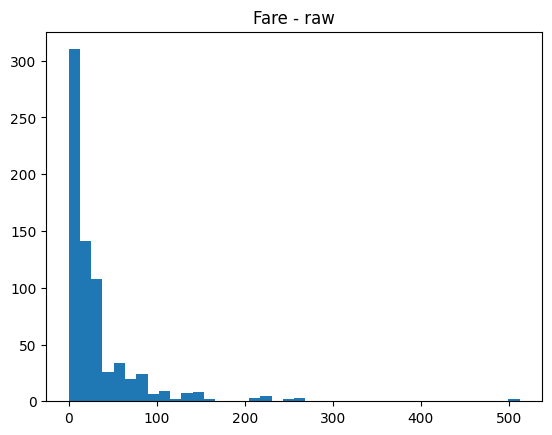

In [9]:
plt.hist(X_train["fare"], bins=40)
plt.title("Fare - raw")
plt.show()

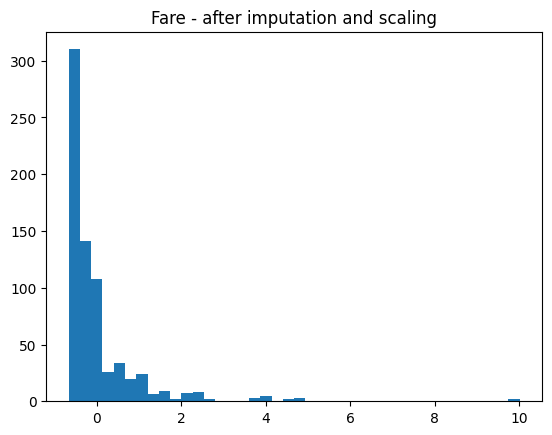

In [10]:
plt.hist(clean["num__fare"], bins=40)
plt.title("Fare - after imputation and scaling")
plt.show()

In [11]:
def build_titanic_pipeline():
    """Return the unfitted preprocessor built in Cells 5, 6 and 7."""
    return ColumnTransformer([
        ("num", numeric_pipe, numeric),
        ("cat", categorical_pipe, categorical),
        ("ord", ordinal_pipe, ordinal),
    ])

def validate_pipeline(pipeline, X_train, X_val):
    train = pipeline.transform(X_train)
    val = pipeline.transform(X_val)

    assert not np.isnan(train).any(), "missing values left in training data"
    assert train.shape[1] == val.shape[1], "train and val columns differ"
    assert train.shape[1] > 6, "too few features - encoders did not run"

    print("Pipeline validation PASSED")
    print("Features:", train.shape[1], " Train rows:", train.shape[0])

pipeline = build_titanic_pipeline()
pipeline.fit(X_train)
validate_pipeline(pipeline, X_train, X_val)

joblib.dump(pipeline, "titanic_preprocessor.joblib")

Pipeline validation PASSED
Features: 11  Train rows: 712


['titanic_preprocessor.joblib']